# MORF 14-3-3 Binding Prediction

This notebook predicts 14-3-3 binding for every sequence in `morf_less_3069_esm2_embed.csv`.

It keeps the requested MORF metadata columns, scores all `S/T` sites for each protein, and saves results in batches so the run can resume after interruptions.


In [1]:
from pathlib import Path
import json

import pandas as pd

from features import predict_sequence_binding


/home/luvul/.conda/envs/1433predictor2026/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
INPUT_CSV = Path("morf_less_3069_esm2_embed.csv")
OUTPUT_DIR = Path("morf_predictions")
BATCH_DIR = OUTPUT_DIR / "batches"
FINAL_OUTPUT = OUTPUT_DIR / "morf_14_3_3_predictions_final.csv"
THRESHOLD = 0.58
BATCH_SIZE = 25

COLUMNS_TO_KEEP = [
    "Name",
    "RefSeq Gene Name",
    "RefSeq and Gencode ID",
    "Isoform ID",
    "Unsorted M1",
    "Unsorted M2",
    "Unsorted M3",
    "Unsorted M4",
    "Unsorted M5",
    "Unsorted M6",
    "Unsorted M7",
    "Sorted M1",
    "Sorted M2",
    "Sorted M3",
    "Sorted M4",
    "Sorted M5",
    "Sorted M6",
    "Sorted M7",
    "protein_seq",
]

OUTPUT_DIR.mkdir(exist_ok=True)
BATCH_DIR.mkdir(exist_ok=True)


In [3]:
morf_df = pd.read_csv(INPUT_CSV, low_memory=False)
morf_df = morf_df.reset_index().rename(columns={"index": "row_id"})
morf_df = morf_df[["row_id", *COLUMNS_TO_KEEP]].copy()
morf_df["protein_seq"] = morf_df["protein_seq"].fillna("").astype(str)

morf_df.head()


,row_id,Name,RefSeq Gene Name,RefSeq and Gencode ID,Isoform ID,Unsorted M1,Unsorted M2,Unsorted M3,Unsorted M4,Unsorted M5,Unsorted M6,Unsorted M7,Sorted M1,Sorted M2,Sorted M3,Sorted M4,Sorted M5,Sorted M6,Sorted M7,protein_seq
0,0,TFORF0001,HIF3A,"NM_022462,ENST00000244303",HIF3A-1,0.7414774375,0.716646256,0.6438623765,0.7424874095,0.753406193,0.6992798395,0.739478308,0.5832873715,1.2392466185,0.4941610715,0.6084341470000001,0.845343945,0.41613094749999996,0.8065738665,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCAC...
1,1,TFORF0002,HIF3A,"NM_152796,ENST00000472815",HIF3A-2,1.1545376955,1.162654729,1.1874625055,1.158854393,1.2307572235,1.1909042865,1.157485845,1.148422318,0.6263125975,0.5061714795,0.6141420664999999,1.001454306,0.4227059445,0.6539290019999999,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCAC...
2,2,TFORF0003,HIF3A,"NM_152794,ENST00000300862",HIF3A-3,0.452996483,0.457956414,0.5006677625,0.469695383,0.5019223735,0.447660996,0.44845887500000003,2.272696743,0.856027864,0.733961733,0.856930972,0.9717059910000001,1.20201072,1.3187659040000002,MDWQDHRSTTELRKEKSRDAARSRRSQETEVLYQLAHTLPFARGVS...
3,3,TFORF0004,HIF3A,"XM_005259153,ENST00000600383",HIF3A-4,0.737029494,0.668277681,0.7258094850000001,0.7001042495,0.7197554595,0.7426571935,0.7697450715,0.7099893875000001,0.968795771,0.565647477,0.558274185,0.6376487495000001,0.551870697,1.0364776455000002,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCAC...
4,4,TFORF0005,HIF3A,"NM_152795,ENST00000377670",HIF3A-5,0.49517536250000005,0.5020868695,0.5125961889999999,0.5607456344999999,0.4979015705,0.4774604485,0.502449455,0.5911060775,0.5742731415,0.9185268065000001,0.657410973,1.2068972375,1.0359074225,0.6155809015,MALGLQRARSTTELRKEKSRDAARSRRSQETEVLYQLAHTLPFARG...


In [4]:
def list_batch_files(batch_dir):
    return sorted(batch_dir.glob("batch_*.csv"))


def load_processed_row_ids(batch_dir):
    processed = set()
    for batch_file in list_batch_files(batch_dir):
        batch_df = pd.read_csv(batch_file, usecols=["row_id"])
        processed.update(batch_df["row_id"].astype(int).tolist())
    return processed


def format_positive_site_outputs(site_results_df):
    positive_df = site_results_df[site_results_df["predicted_positive"]].copy()
    positive_df = positive_df.sort_values(["positive_probability", "site"], ascending=[False, True])
    positive_sites = positive_df["site"].astype(int).tolist()
    positive_site_probabilities = [
        {
            "site": int(row.site),
            "residue": row.residue,
            "probability": float(row.positive_probability),
        }
        for row in positive_df.itertuples()
    ]
    return positive_sites, positive_site_probabilities


def predict_morf_row(row, threshold):
    sequence = row["protein_seq"].strip()
    if not sequence:
        return {
            "row_id": int(row["row_id"]),
            "sequence_binding_14_3_3": None,
            "best_site": None,
            "best_residue": None,
            "best_site_probability": None,
            "deephase_w2v_multi": None,
            "site_count": 0,
            "positive_sites": json.dumps([]),
            "positive_site_probabilities": json.dumps([]),
            "threshold": float(threshold),
            "prediction_status": "error",
            "error_message": "Empty sequence",
        }

    try:
        summary, site_results_df, prediction_features_df, _ = predict_sequence_binding(sequence, threshold=threshold)
        deephase_w2v_multi = float(prediction_features_df["deephase_w2v_multi"].iloc[0])
        positive_sites, positive_site_probabilities = format_positive_site_outputs(site_results_df)
        return {
            "row_id": int(row["row_id"]),
            "sequence_binding_14_3_3": bool(summary["predicted_positive"]),
            "best_site": int(summary["best_site"]),
            "best_residue": summary["best_residue"],
            "best_site_probability": float(summary["max_probability"]),
            "deephase_w2v_multi": deephase_w2v_multi,
            "site_count": int(summary["site_count"]),
            "positive_sites": json.dumps(positive_sites),
            "positive_site_probabilities": json.dumps(positive_site_probabilities),
            "threshold": float(summary["threshold"]),
            "prediction_status": "ok",
            "error_message": "",
        }
    except Exception as exc:
        return {
            "row_id": int(row["row_id"]),
            "sequence_binding_14_3_3": None,
            "best_site": None,
            "best_residue": None,
            "best_site_probability": None,
            "deephase_w2v_multi": None,
            "site_count": None,
            "positive_sites": json.dumps([]),
            "positive_site_probabilities": json.dumps([]),
            "threshold": float(threshold),
            "prediction_status": "error",
            "error_message": str(exc),
        }


def save_batch(batch_df, batch_index, batch_dir):
    batch_path = batch_dir / f"batch_{batch_index:04d}.csv"
    batch_df.to_csv(batch_path, index=False)
    return batch_path


def combine_saved_batches(batch_dir, source_df, final_output):
    batch_files = list_batch_files(batch_dir)
    if not batch_files:
        return pd.DataFrame()

    predicted_df = pd.concat((pd.read_csv(batch_file) for batch_file in batch_files), ignore_index=True)
    predicted_df = predicted_df.sort_values("row_id").drop_duplicates(subset=["row_id"], keep="last")
    combined_df = source_df.merge(predicted_df, on="row_id", how="left")
    combined_df.to_csv(final_output, index=False)
    return combined_df


In [5]:
processed_row_ids = load_processed_row_ids(BATCH_DIR)
remaining_df = morf_df[~morf_df["row_id"].isin(processed_row_ids)].copy()

print(f"Total sequences: {len(morf_df)}")
print(f"Already processed: {len(processed_row_ids)}")
print(f"Remaining: {len(remaining_df)}")
print(f"Threshold: {THRESHOLD}")
print(f"Batch size: {BATCH_SIZE}")


Total sequences: 3203
Already processed: 1950
Remaining: 1253
Threshold: 0.58
Batch size: 25


In [6]:
if len(remaining_df) == 0:
    print("All rows are already processed.")
else:
    start_batch_index = len(list_batch_files(BATCH_DIR)) + 1

    for batch_offset, start in enumerate(range(0, len(remaining_df), BATCH_SIZE), start=start_batch_index):
        batch_input_df = remaining_df.iloc[start : start + BATCH_SIZE].copy()
        batch_results = []

        for _, row in batch_input_df.iterrows():
            batch_results.append(predict_morf_row(row, THRESHOLD))

        batch_pred_df = pd.DataFrame(batch_results)
        batch_output_df = batch_input_df.merge(batch_pred_df, on="row_id", how="left")
        batch_path = save_batch(batch_output_df, batch_offset, BATCH_DIR)

        print(
            f"Saved {batch_path.name}: rows {int(batch_input_df['row_id'].min())} to {int(batch_input_df['row_id'].max())}"
        )


Saved batch_0129.csv: rows 3200 to 3202


In [7]:
final_df = combine_saved_batches(BATCH_DIR, morf_df, FINAL_OUTPUT)
print(f"Final output saved to: {FINAL_OUTPUT}")
print(f"Rows in final output: {len(final_df)}")

final_df.head()


Final output saved to: morf_predictions/morf_14_3_3_predictions_final.csv
Rows in final output: 3203


,row_id,Name_x,RefSeq Gene Name_x,RefSeq and Gencode ID_x,Isoform ID_x,Unsorted M1_x,Unsorted M2_x,Unsorted M3_x,Unsorted M4_x,Unsorted M5_x,...,best_site,best_residue,best_site_probability,deephase_w2v_multi,site_count,positive_sites,positive_site_probabilities,threshold,prediction_status,error_message
0,0,TFORF0001,HIF3A,"NM_022462,ENST00000244303",HIF3A-1,0.7414774375,0.716646256,0.6438623765,0.7424874095,0.753406193,...,476,S,0.932070,0.848,103,"[476, 457, 342, 503, 101, 395, 528]","[{""site"": 476, ""residue"": ""S"", ""probability"": 0.9320699572563171}, {""site"": 457, ""residue"": ""S"", ""probability"": 0.8981205224990845}, {""site"": 342, ""residue"": ""S"", ""probability"": 0.7701389193534851}, {""site"": 503, ""residue"": ""T"", ""probability"": 0.649258017539978}, {""site"": 101, ""residue"": ""S"", ""probability"": 0.6296511888504028}, {""site"": 395, ""residue"": ""T"", ""probability"": 0.6278992295265198}, {""site"": 528, ""residue"": ""S"", ""probability"": 0.5799089670181274}]",0.58,ok,NaN
1,1,TFORF0002,HIF3A,"NM_152796,ENST00000472815",HIF3A-2,1.1545376955,1.162654729,1.1874625055,1.158854393,1.2307572235,...,342,S,0.821236,0.793,79,"[342, 395, 101]","[{""site"": 342, ""residue"": ""S"", ""probability"": 0.8212357759475708}, {""site"": 395, ""residue"": ""T"", ""probability"": 0.6824025511741638}, {""site"": 101, ""residue"": ""S"", ""probability"": 0.6339967846870422}]",0.58,ok,NaN
2,2,TFORF0003,HIF3A,"NM_152794,ENST00000300862",HIF3A-3,0.452996483,0.457956414,0.5006677625,0.469695383,0.5019223735,...,543,S,0.942658,0.819,106,"[543, 524, 409, 168, 462, 38, 595, 663, 176]","[{""site"": 543, ""residue"": ""S"", ""probability"": 0.9426575899124146}, {""site"": 524, ""residue"": ""S"", ""probability"": 0.8249622583389282}, {""site"": 409, ""residue"": ""S"", ""probability"": 0.7801840901374817}, {""site"": 168, ""residue"": ""S"", ""probability"": 0.6603224277496338}, {""site"": 462, ""residue"": ""T"", ""probability"": 0.6371928453445435}, {""site"": 38, ""residue"": ""T"", ""probability"": 0.6227583885192871}, {""site"": 595, ""residue"": ""S"", ""probability"": 0.6154332756996155}, {""site"": 663, ""residue"": ""S"", ""probability"": 0.5875610113143921}, {""site"": 176, ""residue"": ""T"", ""probability"": 0.5293228626251221}]",0.58,ok,NaN
3,3,TFORF0004,HIF3A,"XM_005259153,ENST00000600383",HIF3A-4,0.737029494,0.668277681,0.7258094850000001,0.7001042495,0.7197554595,...,476,S,0.918799,0.857,101,"[476, 457, 342, 503, 395, 528, 101, 109]","[{""site"": 476, ""residue"": ""S"", ""probability"": 0.9187994003295898}, {""site"": 457, ""residue"": ""S"", ""probability"": 0.8957927227020264}, {""site"": 342, ""residue"": ""S"", ""probability"": 0.7254562973976135}, {""site"": 503, ""residue"": ""T"", ""probability"": 0.6595150232315063}, {""site"": 395, ""residue"": ""T"", ""probability"": 0.6398034691810608}, {""site"": 528, ""residue"": ""S"", ""probability"": 0.6010677814483643}, {""site"": 101, ""residue"": ""S"", ""probability"": 0.5854116082191467}, {""site"": 109, ""residue"": ""T"", ""probability"": 0.5003527998924255}]",0.58,ok,NaN
4,4,TFORF0005,HIF3A,"NM_152795,ENST00000377670",HIF3A-5,0.49517536250000005,0.5020868695,0.5125961889999999,0.5607456344999999,0.4979015705,...,545,S,0.942658,0.816,106,"[545, 526, 411, 12, 464, 170, 40, 597, 665, 178]","[{""site"": 545, ""residue"": ""S"", ""probability"": 0.9426575899124146}, {""site"": 526, ""residue"": ""S"", ""probability"": 0.8404472470283508}, {""site"": 411, ""residue"": ""S"", ""probability"": 0.7801840901374817}, {""site"": 12, ""residue"": ""T"", ""probability"": 0.6576363444328308}, {""site"": 464, ""residue"": ""T"", ""probability"": 0.6371928453445435}, {""site"": 170, ""residue"": ""S"", ""probability"": 0.6311852931976318}, {""site"": 40, ""residue"": ""T"", ""probability"": 0.6212526559829712}, {""site"": 597, ""residue"": ""S"", ""probability"": 0.6154332756996155}, {""site"": 665, ""residue"": ""S"", ""probability"": 0.5875610113143921}, {""site"

In [9]:
final_df[[
    "Name_x",
    "protein_seq_x",
    "sequence_binding_14_3_3",
    "best_site",
    "best_residue",
    "best_site_probability",
    "deephase_w2v_multi",
    "positive_sites",
    "positive_site_probabilities",
    "prediction_status",
    "error_message",
]].head()

,Name_x,protein_seq_x,sequence_binding_14_3_3,best_site,best_residue,best_site_probability,deephase_w2v_multi,positive_sites,positive_site_probabilities,prediction_status,error_message
0,TFORF0001,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCACTASAPQLELIGHSIFDFIHPCDQEELQDALTPQQTLSRRKVEAPTERCFSLRMKSTLTSRGRTLNLKAATWKVLNCSGHMRAYKPPAQTSPAGSPDSEPPLQCLVLICEAIPHPGSLEPPLGRGAFLSRHSLDMKFTYCDDRIAEVAGYSPDDLIGCSAYEYIHALDSDAVSKSIHTLLSKGQAVTGQYRFLARSGGYLWTQTQATVVSGGRGPQSESIVCVHFLISQVEETGVVLSLEQTEQHSRRPIQRGAPSQKDTPNPGDSLDTPGPRILAFLHPPSLSEAALAADPRRFCSPDLRRLLGPILDGASVAATPSTPLATRHPQSPLSADLPDELPVGTENVHRLFTSGKDTEAVETDLDIAQDADALDLEMLAPYISMDDDFQLNASEQLPRAYHRPLGAVPRPRARSFHGLSPPALEPSLLPRWGSDPRLSCSSPSRGDPSASSPMAGARKRTLAQSSEDEDEGVELLGVRPPKRSPSPEHENFLLFPLSLSFLLTGGPAPGSLQDPSTPLLNLNEPLGLGPSLLSPYSDEDTTQPGGPFQPRAGSAQAD,True,476,S,0.932070,0.848,"[476, 457, 342, 503, 101, 395, 528]","[{""site"": 476, ""residue"": ""S"", ""probability"": 0.9320699572563171}, {""site"": 457, ""residue"": ""S"", ""probability"": 0.8981205224990845}, {""site"": 342, ""residue"": ""S"", ""probability"": 0.7701389193534851}, {""site"": 503, ""residue"": ""T"", ""probability"": 0.649258017539978}, {""site"": 101, ""residue"": ""S"", ""probability"": 0.6296511888504028}, {""site"": 395, ""residue"": ""T"", ""probability"": 0.6278992295265198}, {""site"": 528, ""residue"": ""S"", ""probability"": 0.5799089670181274}]",ok,NaN
1,TFORF0002,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCACTASAPQLELIGHSIFDFIHPCDQEELQDALTPQQTLSRRKVEAPTERCFSLRMKSTLTSRGRTLNLKAATWKVLNCSGHMRAYKPPAQTSPAGSPDSEPPLQCLVLICEAIPHPGSLEPPLGRGAFLSRHSLDMKFTYCDDRIAEVAGYSPDDLIGCSAYEYIHALDSDAVSKSIHTLLSKGQAVTGQYRFLARSGGYLWTQTQATVVSGGRGPQSESIVCVHFLISQVEETGVVLSLEQTEQHSRRPIQRGAPSQKDTPNPGDSLDTPGPRILAFLHPPSLSEAALAADPRRFCSPDLRRLLGPILDGASVAATPSTPLATRHPQSPLSADLPDELPVGTENVHRLFTSGKDTEAVETDLDIAQDPSTPLLNLNEPLGFHFVTQSGVQWHKHSSPQPRPPGLK,True,342,S,0.821236,0.793,"[342, 395, 101]","[{""site"": 342, ""residue"": ""S"", ""probability"": 0.8212357759475708}, {""site"": 395, ""residue"": ""T"", ""probability"": 0.6824025511741638}, {""site"": 101, ""residue"": ""S"", ""probability"": 0.6339967846870422}]",ok,NaN
2,TFORF0003,MDWQDHRSTTELRKEKSRDAARSRRSQETEVLYQLAHTLPFARGVSAHLDKASIMRLTISYLRMHRLCAAGEWNQVGAGGEPLDACYLKALEGFVMVLTAEGDMAYLSENVSKHLGLSQLELIGHSIFDFIHPCDQEELQDALTPQQTLSRRKVEAPTERCFSLRMKSTLTSRGRTLNLKAATWKVLNCSGHMRAYKPPAQTSPAGSPDSEPPLQCLVLICEAIPHPGSLEPPLGRGAFLSRHSLDMKFTYCDDRIAEVAGYSPDDLIGCSAYEYIHALDSDAVSKSIHTLLSKGQAVTGQYRFLARSGGYLWTQTQATVVSGGRGPQSESIVCVHFLISQVEETGVVLSLEQTEQHSRRPIQRGAPSQKDTPNPGDSLDTPGPRILAFLHPPSLSEAALAADPRRFCSPDLRRLLGPILDGASVAATPSTPLATRHPQSPLSADLPDELPVGTENVHRLFTSGKDTEAVETDLDIAQDADALDLEMLAPYISMDDDFQLNASEQLPRAYHRPLGAVPRPRARSFHGLSPPALEPSLLPRWGSDPRLSCSSPSRGDPSASSPMAGARKRTLAQSSEDEDEGVELLGVRPPKRSPSPEHENFLLFPLSLSFLLTGGPAPGSLQDPSTPLLNLNEPLGLGPSLLSPYSDEDTTQPGGPFQPRAGSAQAD,True,543,S,0.942658,0.819,"[543, 524, 409, 168, 462, 38, 595, 663, 176]","[{""site"": 543, ""residue"": ""S"", ""probability"": 0.9426575899124146}, {""site"": 524, ""residue"": ""S"", ""probability"": 0.8249622583389282}, {""site"": 409, ""residue"": ""S"", ""probability"": 0.7801840901374817}, {""site"": 168, ""residue"": ""S"", ""probability"": 0.6603224277496338}, {""site"": 462, ""residue"": ""T"", ""probability"": 0.6371928453445435}, {""site"": 38, ""residue"": ""T"", ""probability"": 0.6227583885192871}, {""site"": 595, ""residue"": ""S"", ""probability"": 0.6154332756996155}, {""site"": 663, ""residue"": ""S"", ""probability"": 0.5875610113143921}, {""site"": 176, ""residue"": ""T"", ""probability"": 0.5293228626251221}]",ok,NaN
3,TFORF0004,MRPAAGAARRPRCCTSWLTRCPSPAASAPTWTRPLSCASPSATCACTASAPQLELIGHSIFDFIHPCDQEELQDALTPQQTLSRRKVEAPTERCFSLRMKSTLTSRGRTLNLKAATWKVLNCSGHMRAYKPPAQTSPAGSPDSEPPLQCLVLICEAIPHPGSLEPPLGRGAFLSRHSLDMKFTYCDDRIAEVAGYSPDDLIGCSAYEYIHALDSDAVSKSIHTLLSKGQAVTGQYRFLARSGGYLWTQTQATVVSGGRGPQSESIVCVHFLISQVEETGVVLSLEQTEQHSRRPIQRGAPSQKDTPNPGDSLDTPGPRILAFLHPPSLSEAALAADPRRFCSPDLRRLLGPILDGASVAATPSTPLATRHPQSPLSADLPDELPVGTENVHRLFTSGKDTEAVETDLDIAQDADALDLEMLAPYISMDDDFQ

## Notes

- Re-running the notebook will resume from saved batch files in `morf_predictions/batches`.
- `positive_sites` and `positive_site_probabilities` are stored as JSON strings so they stay intact in CSV output.
- If you want a different binding cutoff, change `THRESHOLD` before running the batch loop.


In [10]:
final_df.columns

Index(['row_id', 'Name_x', 'RefSeq Gene Name_x', 'RefSeq and Gencode ID_x',
       'Isoform ID_x', 'Unsorted M1_x', 'Unsorted M2_x', 'Unsorted M3_x',
       'Unsorted M4_x', 'Unsorted M5_x', 'Unsorted M6_x', 'Unsorted M7_x',
       'Sorted M1_x', 'Sorted M2_x', 'Sorted M3_x', 'Sorted M4_x',
       'Sorted M5_x', 'Sorted M6_x', 'Sorted M7_x', 'protein_seq_x', 'Name_y',
       'RefSeq Gene Name_y', 'RefSeq and Gencode ID_y', 'Isoform ID_y',
       'Unsorted M1_y', 'Unsorted M2_y', 'Unsorted M3_y', 'Unsorted M4_y',
       'Unsorted M5_y', 'Unsorted M6_y', 'Unsorted M7_y', 'Sorted M1_y',
       'Sorted M2_y', 'Sorted M3_y', 'Sorted M4_y', 'Sorted M5_y',
       'Sorted M6_y', 'Sorted M7_y', 'protein_seq_y',
       'sequence_binding_14_3_3', 'best_site', 'best_residue',
       'best_site_probability', 'deephase_w2v_multi', 'site_count',
       'positive_sites', 'positive_site_probabilities', 'threshold',
       'prediction_status', 'error_message'],
      dtype='object')

In [ ]:
# analysis

In [53]:
import pandas as pd

final_df = pd.read_csv("morf_predictions/morf_14_3_3_predictions_final.csv")

Rows used: 3201
Pearson r: PearsonRResult(statistic=-0.2518821018339128, pvalue=1.636874453378855e-47)
Spearman rho: SignificanceResult(statistic=-0.27268886212190596, pvalue=1.08844958558744e-55)


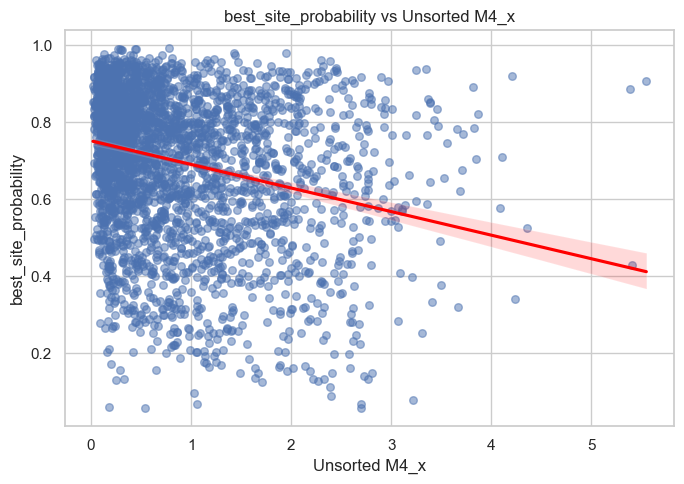

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# df = pd.read_csv("your_file.csv")  # uncomment and set your filename

x = pd.to_numeric(final_df["Unsorted M4_x"], errors="coerce")
y = pd.to_numeric(final_df["best_site_probability"], errors="coerce")

plot_df = pd.DataFrame({"Unsorted M4_x": x, "best_site_probability": y}).dropna()

print("Rows used:", len(plot_df))
print("Pearson r:", pearsonr(plot_df["Unsorted M4_x"], plot_df["best_site_probability"]))
print("Spearman rho:", spearmanr(plot_df["Unsorted M4_x"], plot_df["best_site_probability"]))

sns.set(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.regplot(
    data=plot_df,
    x="Unsorted M4_x",
    y="best_site_probability",
    scatter_kws={"alpha": 0.5, "s": 30},
    line_kws={"color": "red"},
)
plt.title("best_site_probability vs Unsorted M4_x")
plt.tight_layout()
plt.show()

Rows used: 3201
Pearson r: PearsonRResult(statistic=-0.36463408309980294, pvalue=3.032818609366578e-101)
Spearman rho: SignificanceResult(statistic=-0.2479921330725331, pvalue=4.586360500998244e-46)


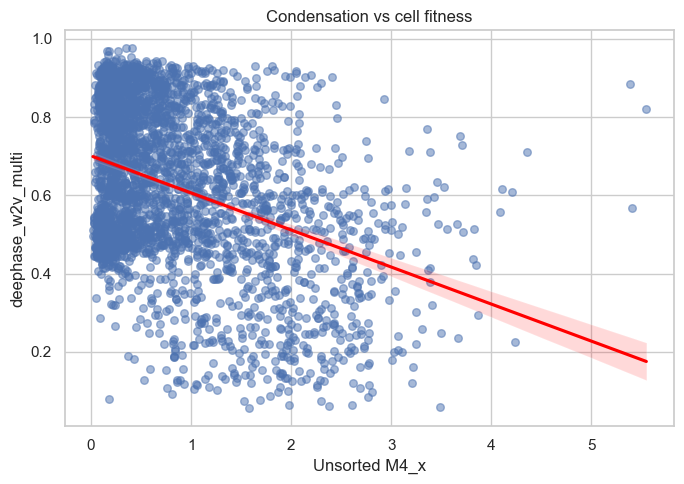

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# df = pd.read_csv("your_file.csv")  # uncomment and set your filename

x = pd.to_numeric(final_df["Unsorted M4_x"], errors="coerce")
y = pd.to_numeric(final_df["deephase_w2v_multi"], errors="coerce")

plot_df = pd.DataFrame({"Unsorted M4_x": x, "deephase_w2v_multi": y}).dropna()

print("Rows used:", len(plot_df))
print("Pearson r:", pearsonr(plot_df["Unsorted M4_x"], plot_df["deephase_w2v_multi"]))
print("Spearman rho:", spearmanr(plot_df["Unsorted M4_x"], plot_df["deephase_w2v_multi"]))

sns.set(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.regplot(
    data=plot_df,
    x="Unsorted M4_x",
    y="deephase_w2v_multi",
    scatter_kws={"alpha": 0.5, "s": 30},
    line_kws={"color": "red"},
)
plt.title("Condensation vs cell fitness")
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, mannwhitneyu, t
from sklearn.linear_model import LinearRegression


# =========================================================
# 0. Utility
# =========================================================
def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


# =========================================================
# 1. Prepare data: all rows
# =========================================================
def prepare_all_row_data(
    df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x"
):
    """
    Keep all rows (no gene deduplication).
    Calculate protein length from protein sequence.
    """
    sub = df[[gene_col, isoform_col, score_col, m4_col, seq_col]].copy()

    sub[score_col] = safe_numeric(sub[score_col])
    sub[m4_col] = safe_numeric(sub[m4_col])

    sub[seq_col] = sub[seq_col].fillna("").astype(str).str.strip()
    sub["protein_length"] = sub[seq_col].str.len()

    sub = sub.dropna(subset=[gene_col, score_col, m4_col])
    sub = sub[sub["protein_length"] > 0].copy()
    sub = sub.reset_index(drop=True)

    return sub


# =========================================================
# 2. Prepare data: gene level
# =========================================================
def prepare_gene_level_data(
    df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x"
):
    """
    For each gene, keep one representative isoform:
    the isoform with the highest score_col.
    """
    sub = prepare_all_row_data(
        df,
        gene_col=gene_col,
        isoform_col=isoform_col,
        score_col=score_col,
        m4_col=m4_col,
        seq_col=seq_col
    )

    gene_rep = (
        sub.sort_values([score_col, m4_col], ascending=[False, False])
           .drop_duplicates(subset=[gene_col], keep="first")
           .reset_index(drop=True)
    )

    return gene_rep


# =========================================================
# 3. Select top / bottom groups
# =========================================================
def select_top_bottom_groups(
    data_df,
    score_col="best_site_probability",
    percent=0.10
):
    n_rows = len(data_df)
    n_select = max(1, int(np.floor(n_rows * percent)))

    top_group = data_df.sort_values(score_col, ascending=False).head(n_select).copy()
    top_group["group"] = "Top 10%"

    bottom_group = data_df.sort_values(score_col, ascending=True).head(n_select).copy()
    bottom_group["group"] = "Bottom 10%"

    return top_group, bottom_group


# =========================================================
# 4. Basic association
# =========================================================
def basic_association(
    data_df,
    score_col="best_site_probability",
    m4_col="Unsorted M4_x"
):
    df_clean = data_df[[score_col, m4_col]].dropna().copy()

    pearson_r, pearson_p = pearsonr(df_clean[score_col], df_clean[m4_col])
    spearman_rho, spearman_p = spearmanr(df_clean[score_col], df_clean[m4_col])

    return {
        "n": len(df_clean),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }


# =========================================================
# 5. Compare top vs bottom groups
# =========================================================
def compare_top_bottom(
    top_group,
    bottom_group,
    m4_col="Unsorted M4_x"
):
    top_vals = safe_numeric(top_group[m4_col]).dropna()
    bottom_vals = safe_numeric(bottom_group[m4_col]).dropna()

    mw_stat, mw_p = mannwhitneyu(top_vals, bottom_vals, alternative="two-sided")

    return {
        "n_top": len(top_vals),
        "n_bottom": len(bottom_vals),
        "top_m4_mean": top_vals.mean(),
        "bottom_m4_mean": bottom_vals.mean(),
        "top_m4_median": top_vals.median(),
        "bottom_m4_median": bottom_vals.median(),
        "mannwhitney_u_stat": mw_stat,
        "mannwhitney_p": mw_p
    }


# =========================================================
# 6. Check length association
# =========================================================
def check_length_association(
    data_df,
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    length_col="protein_length"
):
    df_clean = data_df[[score_col, m4_col, length_col]].dropna().copy()

    r_len_score, p_len_score = pearsonr(df_clean[length_col], df_clean[score_col])
    rho_len_score, sp_len_score = spearmanr(df_clean[length_col], df_clean[score_col])

    r_len_m4, p_len_m4 = pearsonr(df_clean[length_col], df_clean[m4_col])
    rho_len_m4, sp_len_m4 = spearmanr(df_clean[length_col], df_clean[m4_col])

    return {
        "n": len(df_clean),
        "length_vs_score_pearson_r": r_len_score,
        "length_vs_score_pearson_p": p_len_score,
        "length_vs_score_spearman_rho": rho_len_score,
        "length_vs_score_spearman_p": sp_len_score,
        "length_vs_m4_pearson_r": r_len_m4,
        "length_vs_m4_pearson_p": p_len_m4,
        "length_vs_m4_spearman_rho": rho_len_m4,
        "length_vs_m4_spearman_p": sp_len_m4
    }


# =========================================================
# 7. Partial correlation by residuals
# =========================================================
def partial_correlation_by_residuals(
    data_df,
    x_col="best_site_probability",
    y_col="Unsorted M4_x",
    covar_col="protein_length"
):
    df_clean = data_df[[x_col, y_col, covar_col]].dropna().copy()

    X = df_clean[[x_col]].values
    Y = df_clean[[y_col]].values
    Z = df_clean[[covar_col]].values

    model_x = LinearRegression().fit(Z, X)
    X_res = X - model_x.predict(Z)

    model_y = LinearRegression().fit(Z, Y)
    Y_res = Y - model_y.predict(Z)

    partial_pearson_r, partial_pearson_p = pearsonr(X_res.ravel(), Y_res.ravel())
    partial_spearman_rho, partial_spearman_p = spearmanr(X_res.ravel(), Y_res.ravel())

    return {
        "n": len(df_clean),
        "partial_pearson_r": partial_pearson_r,
        "partial_pearson_p": partial_pearson_p,
        "partial_spearman_rho": partial_spearman_rho,
        "partial_spearman_p": partial_spearman_p,
        "x_residuals": X_res.ravel(),
        "y_residuals": Y_res.ravel(),
        "df_clean": df_clean
    }


# =========================================================
# 8. Regression controlling for length
# =========================================================
def regression_controlling_length(
    data_df,
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    length_col="protein_length"
):
    df_clean = data_df[[score_col, m4_col, length_col]].dropna().copy()

    X = df_clean[[score_col, length_col]].values
    y = df_clean[m4_col].values.reshape(-1, 1)

    X_design = np.hstack([np.ones((X.shape[0], 1)), X])

    model = LinearRegression(fit_intercept=False)
    model.fit(X_design, y)

    beta = model.coef_.flatten()
    y_pred = model.predict(X_design)
    residuals = y - y_pred

    n = X_design.shape[0]
    p = X_design.shape[1]

    sigma2 = (residuals.T @ residuals) / (n - p)
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    var_beta = sigma2[0, 0] * XtX_inv
    se_beta = np.sqrt(np.diag(var_beta))

    t_stats = beta / se_beta
    p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n - p))

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    return {
        "variables": ["intercept", score_col, length_col],
        "coefficients": beta,
        "std_error": se_beta,
        "t_stats": t_stats,
        "p_values": p_values,
        "n": n,
        "r_squared": r_squared
    }


# =========================================================
# 9. Plotting
# =========================================================
def plot_all_figures(
    data_df,
    top_group,
    bottom_group,
    partial_results,
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    save_prefix="analysis"
):
    # raw scatter
    raw_df = data_df[[score_col, m4_col]].dropna().copy()
    raw_pearson_r, raw_pearson_p = pearsonr(raw_df[score_col], raw_df[m4_col])
    raw_spearman_rho, raw_spearman_p = spearmanr(raw_df[score_col], raw_df[m4_col])

    plt.figure(figsize=(6, 5))
    plt.scatter(raw_df[score_col], raw_df[m4_col], alpha=0.35, s=18)

    z = np.polyfit(raw_df[score_col], raw_df[m4_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(raw_df[score_col].min(), raw_df[score_col].max(), 200)
    plt.plot(x_line, p(x_line), linewidth=2)

    plt.xlabel(score_col)
    plt.ylabel(m4_col)
    plt.title("Raw association")

    txt = (
        f"Pearson r = {raw_pearson_r:.3f}, p = {raw_pearson_p:.2e}\n"
        f"Spearman rho = {raw_spearman_rho:.3f}, p = {raw_spearman_p:.2e}\n"
        f"n = {len(raw_df)}"
    )
    plt.text(
        0.03, 0.97, txt,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_raw_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

    # partial residual scatter
    x_res = partial_results["x_residuals"]
    y_res = partial_results["y_residuals"]

    plt.figure(figsize=(6, 5))
    plt.scatter(x_res, y_res, alpha=0.35, s=18)

    z = np.polyfit(x_res, y_res, 1)
    p = np.poly1d(z)
    x_line = np.linspace(np.min(x_res), np.max(x_res), 200)
    plt.plot(x_line, p(x_line), linewidth=2)

    plt.xlabel(f"{score_col} residuals\n(controlling for protein length)")
    plt.ylabel(f"{m4_col} residuals\n(controlling for protein length)")
    plt.title("Partial correlation controlling for protein length")

    txt = (
        f"Partial Pearson r = {partial_results['partial_pearson_r']:.3f}, "
        f"p = {partial_results['partial_pearson_p']:.2e}\n"
        f"Partial Spearman rho = {partial_results['partial_spearman_rho']:.3f}, "
        f"p = {partial_results['partial_spearman_p']:.2e}\n"
        f"n = {partial_results['n']}"
    )
    plt.text(
        0.03, 0.97, txt,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_partial_residual_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

    # boxplot
    plot_df = pd.concat([top_group, bottom_group], axis=0).copy()
    plot_df[m4_col] = safe_numeric(plot_df[m4_col])
    plot_df = plot_df.dropna(subset=[m4_col])

    top_vals = plot_df.loc[plot_df["group"] == "Top 10%", m4_col]
    bottom_vals = plot_df.loc[plot_df["group"] == "Bottom 10%", m4_col]
    mw_stat, mw_p = mannwhitneyu(top_vals, bottom_vals, alternative="two-sided")

    plt.figure(figsize=(5, 5))
    plt.boxplot(
        [top_vals, bottom_vals],
        labels=["Top 10%", "Bottom 10%"],
        showfliers=False
    )
    plt.ylabel(m4_col)
    plt.title("Top vs Bottom score groups")

    txt = (
        f"Top median = {top_vals.median():.3f}\n"
        f"Bottom median = {bottom_vals.median():.3f}\n"
        f"Mann-Whitney p = {mw_p:.2e}"
    )
    plt.text(
        0.03, 0.97, txt,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_top_bottom_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()


# =========================================================
# 10. Run one mode
# =========================================================
def run_one_analysis_mode(
    input_df,
    mode_name,
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    percent=0.10,
    save_prefix="analysis"
):
    top_group, bottom_group = select_top_bottom_groups(
        input_df,
        score_col=score_col,
        percent=percent
    )

    raw_results = basic_association(
        input_df,
        score_col=score_col,
        m4_col=m4_col
    )

    group_results = compare_top_bottom(
        top_group,
        bottom_group,
        m4_col=m4_col
    )

    length_results = check_length_association(
        input_df,
        score_col=score_col,
        m4_col=m4_col,
        length_col="protein_length"
    )

    partial_results = partial_correlation_by_residuals(
        input_df,
        x_col=score_col,
        y_col=m4_col,
        covar_col="protein_length"
    )

    regression_results = regression_controlling_length(
        input_df,
        score_col=score_col,
        m4_col=m4_col,
        length_col="protein_length"
    )

    plot_all_figures(
        input_df,
        top_group,
        bottom_group,
        partial_results,
        score_col=score_col,
        m4_col=m4_col,
        save_prefix=save_prefix
    )

    return {
        "mode": mode_name,
        "data": input_df,
        "top_group": top_group,
        "bottom_group": bottom_group,
        "raw_results": raw_results,
        "group_results": group_results,
        "length_results": length_results,
        "partial_results": {
            k: v for k, v in partial_results.items()
            if k not in ["x_residuals", "y_residuals", "df_clean"]
        },
        "regression_results": regression_results
    }


# =========================================================
# 11. Full wrapper: both all-row and gene-level
# =========================================================
def run_full_dual_analysis(
    final_df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x",
    percent=0.10,
    save_prefix_base="binding_m4_analysis"
):
    # all rows
    all_row_df = prepare_all_row_data(
        final_df,
        gene_col=gene_col,
        isoform_col=isoform_col,
        score_col=score_col,
        m4_col=m4_col,
        seq_col=seq_col
    )

    # gene level
    gene_level_df = prepare_gene_level_data(
        final_df,
        gene_col=gene_col,
        isoform_col=isoform_col,
        score_col=score_col,
        m4_col=m4_col,
        seq_col=seq_col
    )

    all_row_results = run_one_analysis_mode(
        all_row_df,
        mode_name="all_rows",
        score_col=score_col,
        m4_col=m4_col,
        percent=percent,
        save_prefix=f"{save_prefix_base}_all_rows"
    )

    gene_level_results = run_one_analysis_mode(
        gene_level_df,
        mode_name="gene_level",
        score_col=score_col,
        m4_col=m4_col,
        percent=percent,
        save_prefix=f"{save_prefix_base}_gene_level"
    )

    return {
        "all_rows": all_row_results,
        "gene_level": gene_level_results
    }


# =========================================================
# 12. Pretty print
# =========================================================
def print_regression_results(reg):
    print(f"n = {reg['n']}")
    print(f"R^2 = {reg['r_squared']:.4f}")
    for var, coef, se, tval, pval in zip(
        reg["variables"],
        reg["coefficients"],
        reg["std_error"],
        reg["t_stats"],
        reg["p_values"]
    ):
        print(f"{var:25s} coef={coef: .6f}, SE={se:.6f}, t={tval:.3f}, p={pval:.2e}")


def print_analysis_block(results_dict, title):
    print(f"\n{'='*20} {title} {'='*20}")
    print("\n=== Raw association ===")
    print(results_dict["raw_results"])

    print("\n=== Top vs Bottom comparison ===")
    print(results_dict["group_results"])

    print("\n=== Length association check ===")
    print(results_dict["length_results"])

    print("\n=== Partial correlation controlling for protein length ===")
    print(results_dict["partial_results"])

    print("\n=== Regression controlling for protein length ===")
    print_regression_results(results_dict["regression_results"])


# =========================================================
# 13. RUN
# =========================================================
# Change score_col here if needed:
#   score_col="best_site_probability"
#   score_col="deephase_w2v_multi"

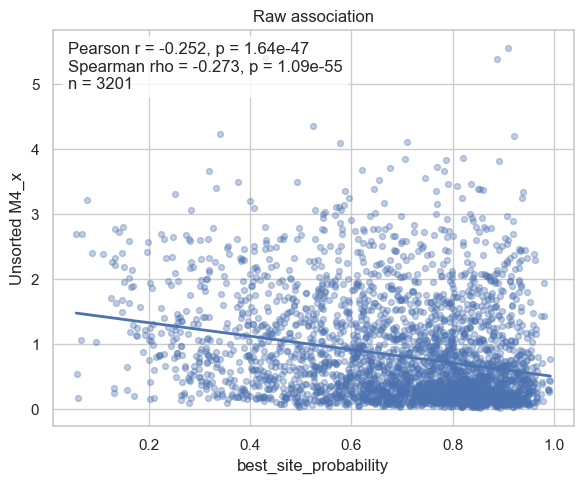

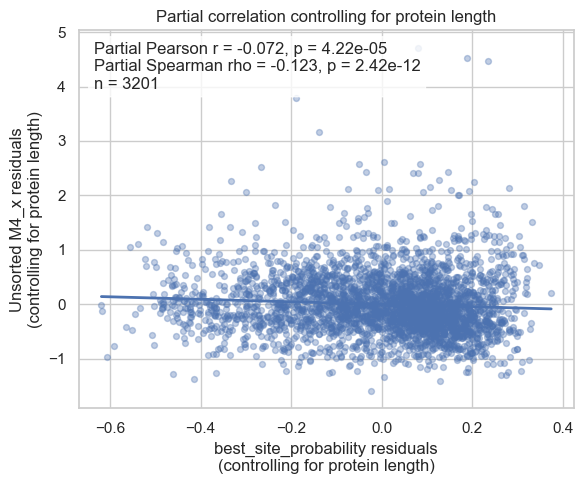

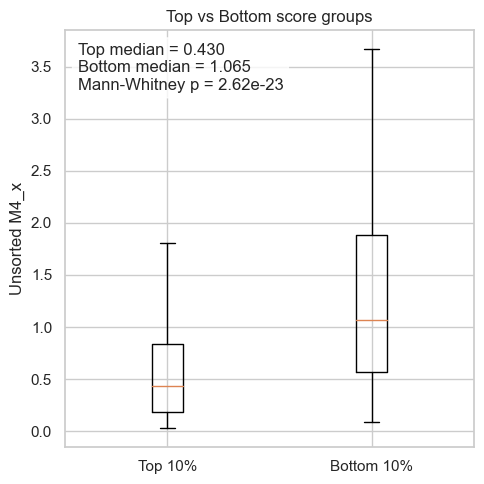

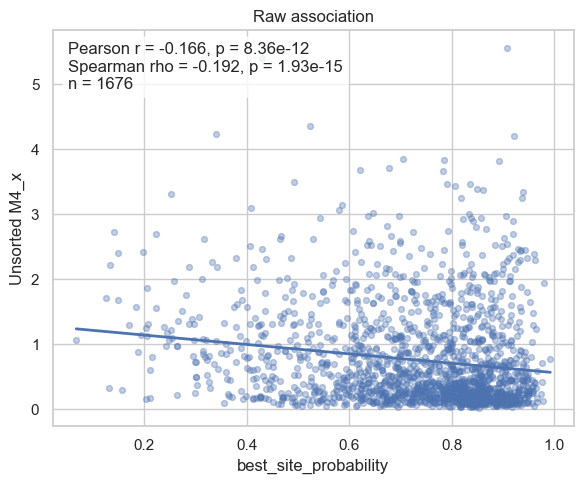

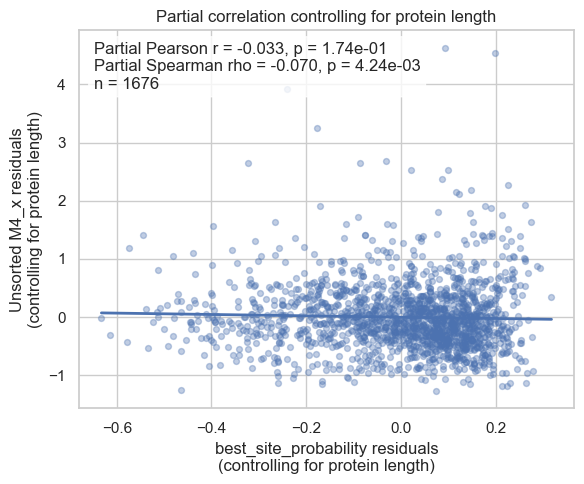

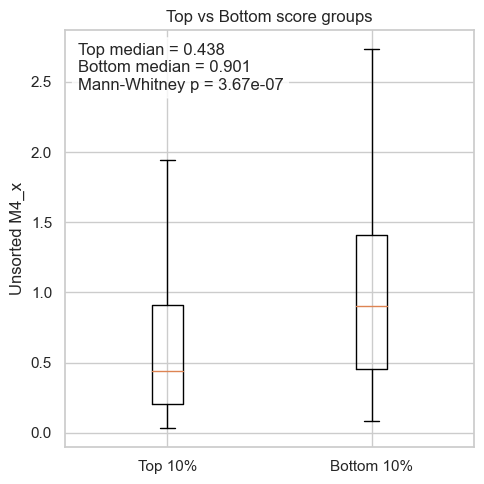


==================== ALL ROWS (NO GENE DEDUP) ====================

=== Raw association ===
{'n': 3201, 'pearson_r': -0.2518821018339128, 'pearson_p': 1.636874453378855e-47, 'spearman_rho': -0.27268886212190596, 'spearman_p': 1.08844958558744e-55}

=== Top vs Bottom comparison ===
{'n_top': 320, 'n_bottom': 320, 'top_m4_mean': 0.691765802134375, 'bottom_m4_mean': 1.2325448013140625, 'top_m4_median': 0.429684464, 'bottom_m4_median': 1.0648962437500002, 'mannwhitney_u_stat': 27938.0, 'mannwhitney_p': 2.6247008983022402e-23}

=== Length association check ===
{'n': 3201, 'length_vs_score_pearson_r': 0.29579365696561744, 'length_vs_score_pearson_p': 1.1861517760147972e-65, 'length_vs_score_spearman_rho': 0.2720493509214303, 'length_vs_score_spearman_p': 1.9916105453119194e-55, 'length_vs_m4_pearson_r': -0.6804007612573719, 'length_vs_m4_pearson_p': 0.0, 'length_vs_m4_spearman_rho': -0.750525690847178, 'length_vs_m4_spearman_p': 0.0}

=== Partial correlation controlling for protein length =

In [57]:
#14-3-3 vs fitness
results = run_full_dual_analysis(
    final_df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="best_site_probability",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x",
    percent=0.10,
    save_prefix_base="best_site_probability_vs_m4"
)

print_analysis_block(results["all_rows"], "ALL ROWS (NO GENE DEDUP)")
print_analysis_block(results["gene_level"], "GENE LEVEL (DEDUP)")

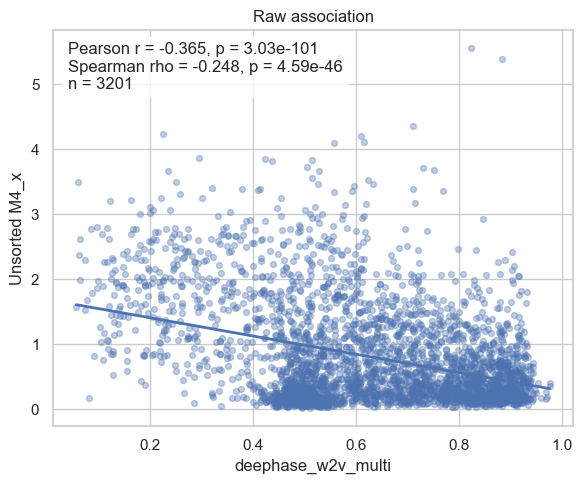

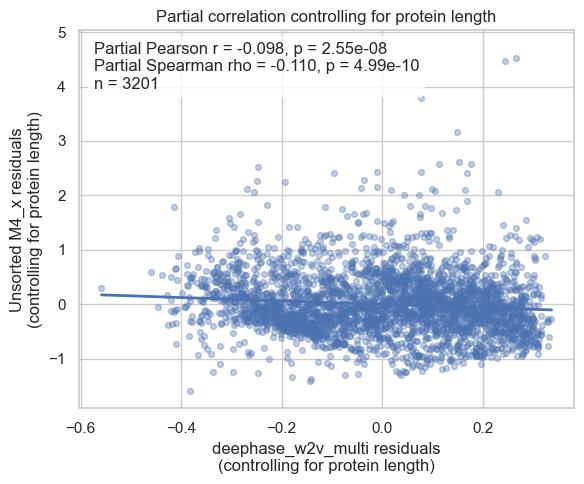

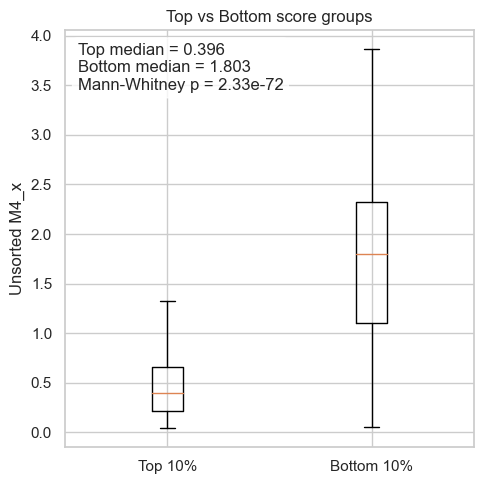

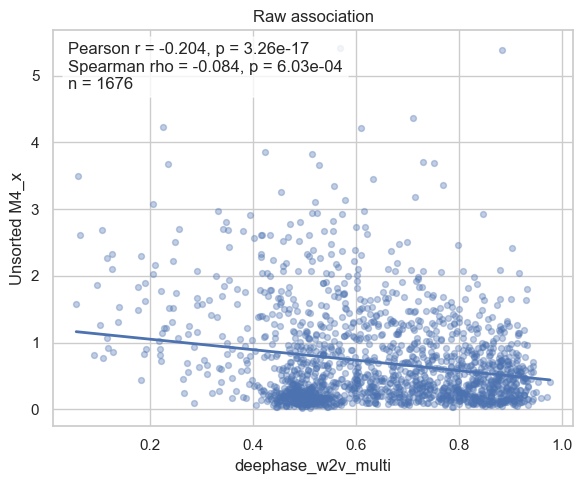

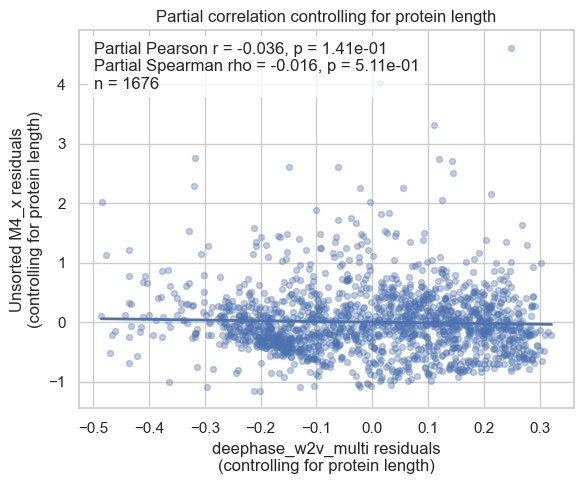

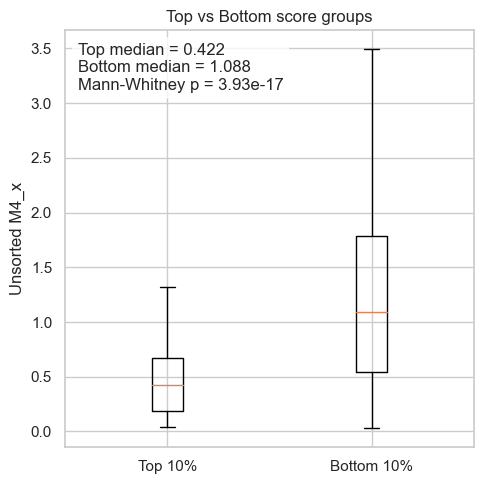


==================== ALL ROWS (NO GENE DEDUP) ====================

=== Raw association ===
{'n': 3201, 'pearson_r': -0.36463408309980294, 'pearson_p': 3.032818609366578e-101, 'spearman_rho': -0.2479921330725331, 'spearman_p': 4.586360500998244e-46}

=== Top vs Bottom comparison ===
{'n_top': 320, 'n_bottom': 320, 'top_m4_mean': 0.530295390121875, 'bottom_m4_mean': 1.7467081226843753, 'top_m4_median': 0.39628656374999993, 'bottom_m4_median': 1.802670579, 'mannwhitney_u_stat': 9125.0, 'mannwhitney_p': 2.334572600251932e-72}

=== Length association check ===
{'n': 3201, 'length_vs_score_pearson_r': 0.4409395968426071, 'length_vs_score_pearson_p': 2.082677864240476e-152, 'length_vs_score_spearman_rho': 0.4023261769981371, 'length_vs_score_spearman_p': 7.650783997078928e-125, 'length_vs_m4_pearson_r': -0.6804007612573719, 'length_vs_m4_pearson_p': 0.0, 'length_vs_m4_spearman_rho': -0.750525690847178, 'length_vs_m4_spearman_p': 0.0}

=== Partial correlation controlling for protein length =

In [58]:
#condensation vs fitness
results = run_full_dual_analysis(
    final_df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="deephase_w2v_multi",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x",
    percent=0.10,
    save_prefix_base="best_site_probability_vs_m4"
)

print_analysis_block(results["all_rows"], "ALL ROWS (NO GENE DEDUP)")
print_analysis_block(results["gene_level"], "GENE LEVEL (DEDUP)")

In [59]:
final_df.columns

Index(['row_id', 'Name_x', 'RefSeq Gene Name_x', 'RefSeq and Gencode ID_x',
       'Isoform ID_x', 'Unsorted M1_x', 'Unsorted M2_x', 'Unsorted M3_x',
       'Unsorted M4_x', 'Unsorted M5_x', 'Unsorted M6_x', 'Unsorted M7_x',
       'Sorted M1_x', 'Sorted M2_x', 'Sorted M3_x', 'Sorted M4_x',
       'Sorted M5_x', 'Sorted M6_x', 'Sorted M7_x', 'protein_seq_x', 'Name_y',
       'RefSeq Gene Name_y', 'RefSeq and Gencode ID_y', 'Isoform ID_y',
       'Unsorted M1_y', 'Unsorted M2_y', 'Unsorted M3_y', 'Unsorted M4_y',
       'Unsorted M5_y', 'Unsorted M6_y', 'Unsorted M7_y', 'Sorted M1_y',
       'Sorted M2_y', 'Sorted M3_y', 'Sorted M4_y', 'Sorted M5_y',
       'Sorted M6_y', 'Sorted M7_y', 'protein_seq_y',
       'sequence_binding_14_3_3', 'best_site', 'best_residue',
       'best_site_probability', 'deephase_w2v_multi', 'site_count',
       'positive_sites', 'positive_site_probabilities', 'threshold',
       'prediction_status', 'error_message'],
      dtype='object')

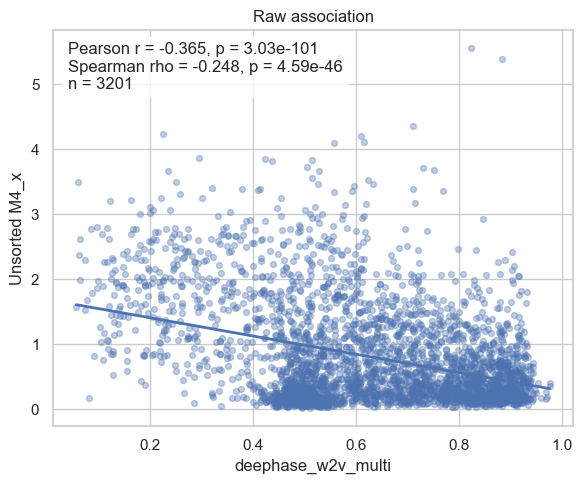

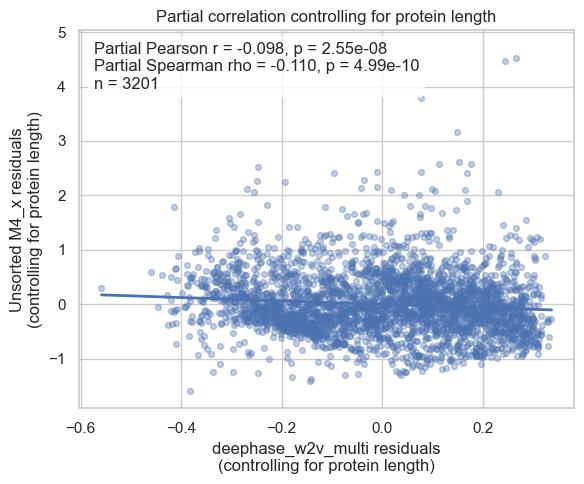

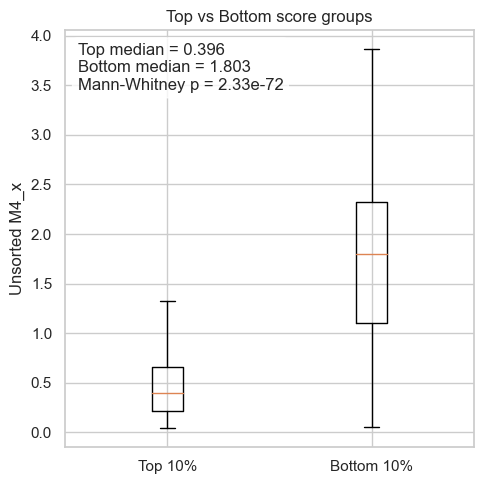

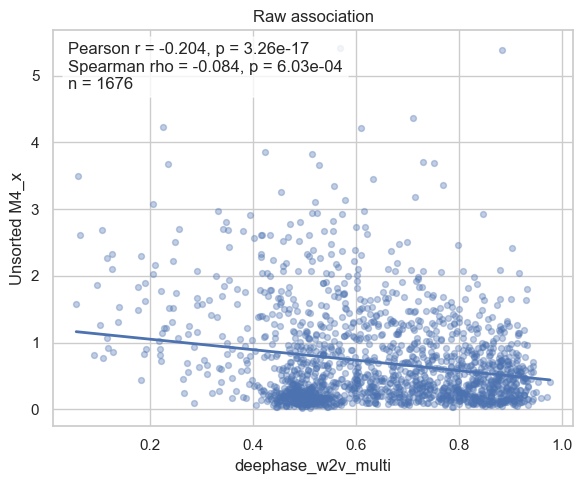

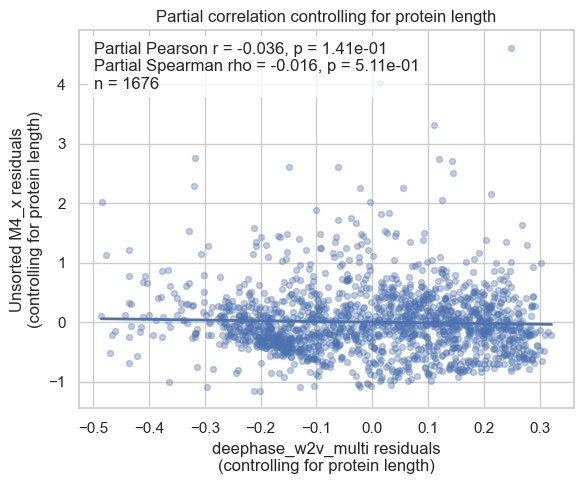

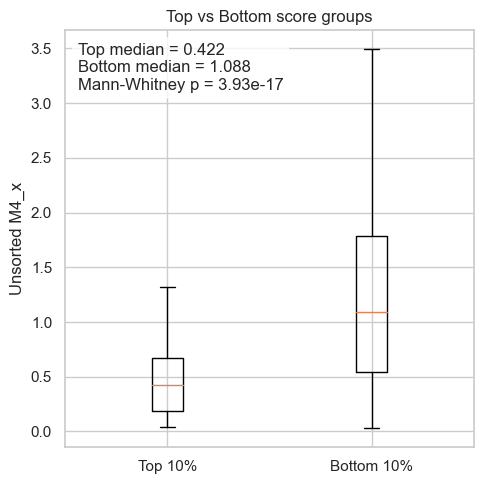


==================== ALL ROWS (NO GENE DEDUP) ====================

=== Raw association ===
{'n': 3201, 'pearson_r': -0.36463408309980294, 'pearson_p': 3.032818609366578e-101, 'spearman_rho': -0.2479921330725331, 'spearman_p': 4.586360500998244e-46}

=== Top vs Bottom comparison ===
{'n_top': 320, 'n_bottom': 320, 'top_m4_mean': 0.530295390121875, 'bottom_m4_mean': 1.7467081226843753, 'top_m4_median': 0.39628656374999993, 'bottom_m4_median': 1.802670579, 'mannwhitney_u_stat': 9125.0, 'mannwhitney_p': 2.334572600251932e-72}

=== Length association check ===
{'n': 3201, 'length_vs_score_pearson_r': 0.4409395968426071, 'length_vs_score_pearson_p': 2.082677864240476e-152, 'length_vs_score_spearman_rho': 0.4023261769981371, 'length_vs_score_spearman_p': 7.650783997078928e-125, 'length_vs_m4_pearson_r': -0.6804007612573719, 'length_vs_m4_pearson_p': 0.0, 'length_vs_m4_spearman_rho': -0.750525690847178, 'length_vs_m4_spearman_p': 0.0}

=== Partial correlation controlling for protein length =

In [60]:
#condensation vs differentiation
results = run_full_dual_analysis(
    final_df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="deephase_w2v_multi",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x",
    percent=0.10,
    save_prefix_base="best_site_probability_vs_m4"
)

print_analysis_block(results["all_rows"], "ALL ROWS (NO GENE DEDUP)")
print_analysis_block(results["gene_level"], "GENE LEVEL (DEDUP)")

=== Data used ===
Rows used: 3201

=== Reduced model ===
Unsorted M4_x ~ protein_length + Sorted M4_x
R^2 = 0.4767

=== Full model ===
Unsorted M4_x ~ protein_length + Sorted M4_x + deephase_w2v_multi
R^2 = 0.4803
intercept            coef= 2.182663, SE=0.033951, t=64.290, p=0.00e+00
protein_length       coef=-0.002445, SE=0.000053, t=-45.763, p=0.00e+00
Sorted M4_x          coef=-0.040322, SE=0.004664, t=-8.645, p=0.00e+00
deephase_w2v_multi   coef=-0.258586, SE=0.054979, t=-4.703, p=2.67e-06

=== Extra variance explained by deephase_w2v_multi ===
Delta R^2 = 0.0036 (0.36% additional variance explained)
Partial Pearson r = -0.0829, p = 2.65e-06


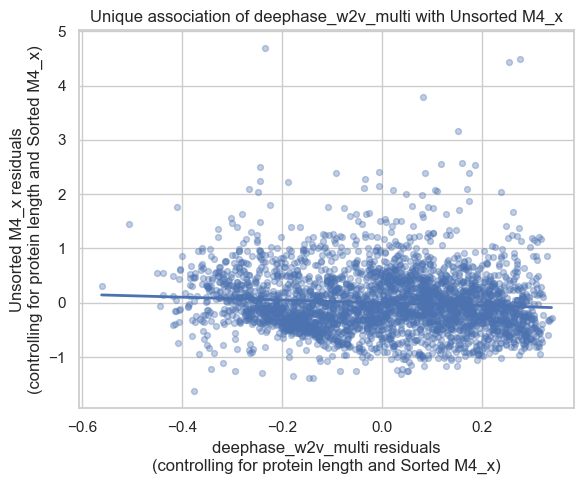

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t


def prepare_unsorted_m4_multivar_data(
    df,
    target_col="Unsorted M4_x",
    sorted_m4_col="Sorted M4_x",
    deephase_col="deephase_w2v_multi",
    seq_col="protein_seq_x"
):
    sub = df[[target_col, sorted_m4_col, deephase_col, seq_col]].copy()

    sub[target_col] = pd.to_numeric(sub[target_col], errors="coerce")
    sub[sorted_m4_col] = pd.to_numeric(sub[sorted_m4_col], errors="coerce")
    sub[deephase_col] = pd.to_numeric(sub[deephase_col], errors="coerce")
    sub[seq_col] = sub[seq_col].fillna("").astype(str).str.strip()
    sub["protein_length"] = sub[seq_col].str.len()

    sub = sub.dropna(subset=[target_col, sorted_m4_col, deephase_col])
    sub = sub[sub["protein_length"] > 0].reset_index(drop=True)
    return sub


def fit_ols(df, predictors, target):
    X = df[predictors].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float).reshape(-1, 1)

    X_design = np.column_stack([np.ones(len(df)), X])
    beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
    y_pred = X_design @ beta
    residuals = y - y_pred

    n = X_design.shape[0]
    p = X_design.shape[1]
    ss_res = float((residuals.T @ residuals)[0, 0])
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r_squared = 1 - ss_res / ss_tot

    sigma2 = ss_res / (n - p)
    xtx_inv = np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(sigma2 * xtx_inv))
    coef = beta.ravel()
    t_stats = coef / se
    p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n - p))

    return {
        "variables": ["intercept"] + predictors,
        "coefficients": coef,
        "std_error": se,
        "t_stats": t_stats,
        "p_values": p_values,
        "r_squared": r_squared,
        "n": n,
        "residuals": residuals.ravel(),
        "fitted": y_pred.ravel(),
    }


def residualize(df, y_col, x_cols):
    X = df[x_cols].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    X_design = np.column_stack([np.ones(len(df)), X])
    beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
    return y - X_design @ beta


analysis_df = prepare_unsorted_m4_multivar_data(final_df)

full_predictors = ["protein_length", "Sorted M4_x", "deephase_w2v_multi"]
base_predictors = ["protein_length", "Sorted M4_x"]

full_model = fit_ols(analysis_df, full_predictors, "Unsorted M4_x")
base_model = fit_ols(analysis_df, base_predictors, "Unsorted M4_x")

delta_r2 = full_model["r_squared"] - base_model["r_squared"]

unsorted_resid = residualize(analysis_df, "Unsorted M4_x", base_predictors)
deephase_resid = residualize(analysis_df, "deephase_w2v_multi", base_predictors)
partial_r, partial_p = pearsonr(deephase_resid, unsorted_resid)

print("=== Data used ===")
print(f"Rows used: {len(analysis_df)}")
print()
print("=== Reduced model ===")
print("Unsorted M4_x ~ protein_length + Sorted M4_x")
print(f"R^2 = {base_model['r_squared']:.4f}")
print()
print("=== Full model ===")
print("Unsorted M4_x ~ protein_length + Sorted M4_x + deephase_w2v_multi")
print(f"R^2 = {full_model['r_squared']:.4f}")
for var, coef, se, t_stat, p_val in zip(
    full_model["variables"],
    full_model["coefficients"],
    full_model["std_error"],
    full_model["t_stats"],
    full_model["p_values"],
):
    print(f"{var:20s} coef={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")
print()
print("=== Extra variance explained by deephase_w2v_multi ===")
print(f"Delta R^2 = {delta_r2:.4f} ({delta_r2 * 100:.2f}% additional variance explained)")
print(f"Partial Pearson r = {partial_r:.4f}, p = {partial_p:.2e}")

plot_df = pd.DataFrame({
    "deephase_residual": deephase_resid,
    "unsorted_m4_residual": unsorted_resid,
})

plt.figure(figsize=(6, 5))
plt.scatter(plot_df["deephase_residual"], plot_df["unsorted_m4_residual"], alpha=0.35, s=18)
z = np.polyfit(plot_df["deephase_residual"], plot_df["unsorted_m4_residual"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(plot_df["deephase_residual"].min(), plot_df["deephase_residual"].max(), 200)
plt.plot(x_line, p_line(x_line), linewidth=2)
plt.xlabel("deephase_w2v_multi residuals\n(controlling for protein length and Sorted M4_x)")
plt.ylabel("Unsorted M4_x residuals\n(controlling for protein length and Sorted M4_x)")
plt.title("Unique association of deephase_w2v_multi with Unsorted M4_x")
plt.tight_layout()
plt.show()


=== Standardized regression (z-score) ===
All predictors and the outcome were z-scored before fitting.
Reduced model R^2 = 0.4767
Full model R^2 = 0.4803
Delta R^2 = 0.0036

Standardized beta coefficients from the full model:
intercept            beta= 0.000000, SE=0.012750, t=0.000, p=1.00e+00
protein_length       beta=-0.650809, SE=0.014221, t=-45.763, p=0.00e+00
Sorted M4_x          beta=-0.110845, SE=0.012822, t=-8.645, p=0.00e+00
deephase_w2v_multi   beta=-0.067189, SE=0.014285, t=-4.703, p=2.67e-06


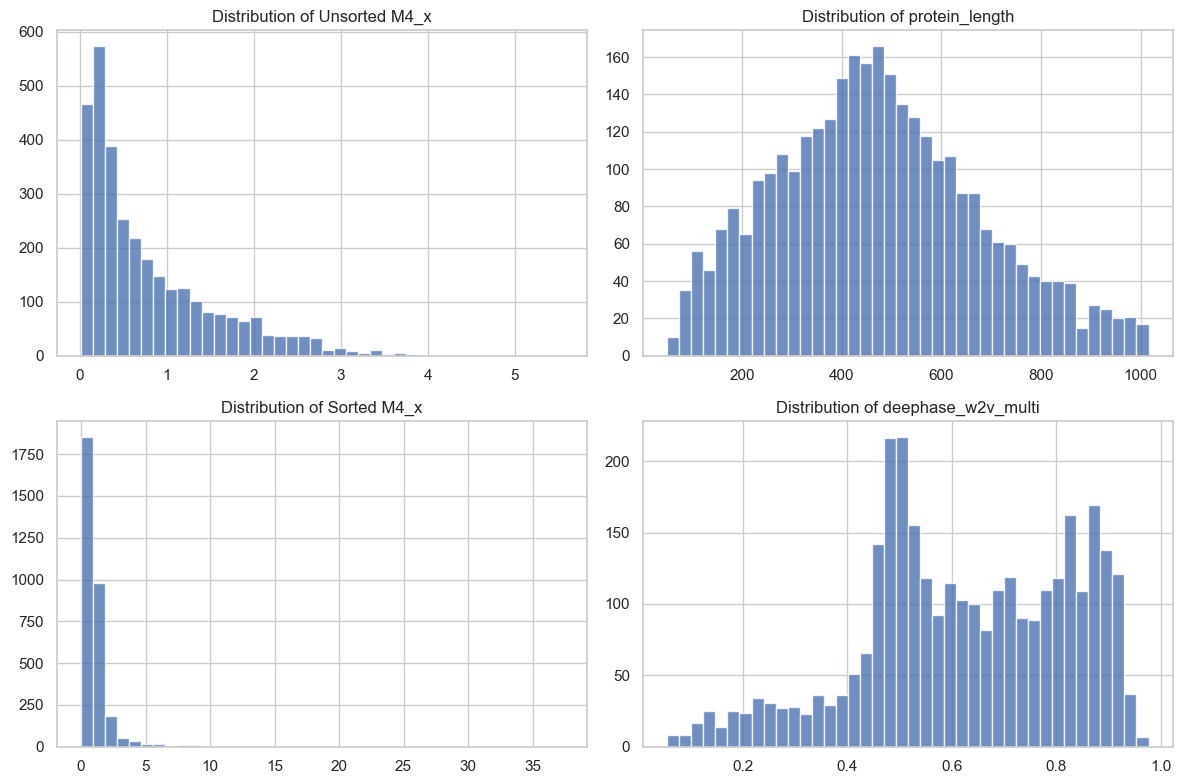

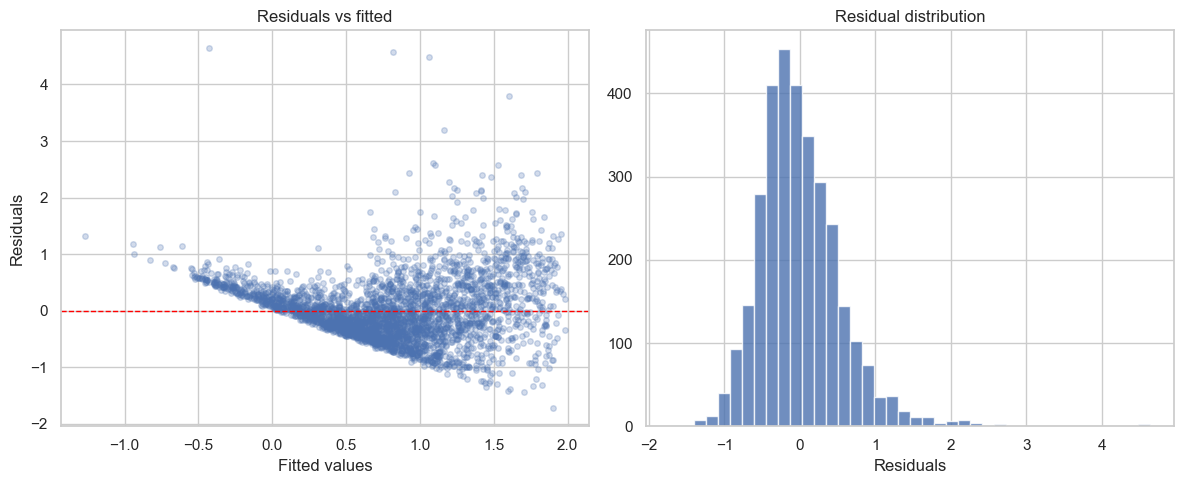

=== How to read this block ===
1. The standardized beta values let you compare predictor effect sizes on the same scale.
2. R^2 and Delta R^2 should match the unstandardized model up to numerical precision.
3. If the raw distributions or residual plots look strongly skewed, curved, or heteroscedastic, then a transform or robust model may be worth trying next.


In [62]:
import seaborn as sns


def zscore_series(series):
    std = series.std(ddof=0)
    if std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


z_df = analysis_df.copy()
z_cols = ["Unsorted M4_x", "protein_length", "Sorted M4_x", "deephase_w2v_multi"]
for col in z_cols:
    z_df[col] = zscore_series(z_df[col])

z_base_model = fit_ols(z_df, ["protein_length", "Sorted M4_x"], "Unsorted M4_x")
z_full_model = fit_ols(z_df, ["protein_length", "Sorted M4_x", "deephase_w2v_multi"], "Unsorted M4_x")

print("=== Standardized regression (z-score) ===")
print("All predictors and the outcome were z-scored before fitting.")
print(f"Reduced model R^2 = {z_base_model['r_squared']:.4f}")
print(f"Full model R^2 = {z_full_model['r_squared']:.4f}")
print(f"Delta R^2 = {z_full_model['r_squared'] - z_base_model['r_squared']:.4f}")
print()
print("Standardized beta coefficients from the full model:")
for var, coef, se, t_stat, p_val in zip(
    z_full_model["variables"],
    z_full_model["coefficients"],
    z_full_model["std_error"],
    z_full_model["t_stats"],
    z_full_model["p_values"],
):
    print(f"{var:20s} beta={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")

raw_cols = ["Unsorted M4_x", "protein_length", "Sorted M4_x", "deephase_w2v_multi"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, raw_cols):
    values = analysis_df[col].to_numpy(dtype=float)
    ax.hist(values, bins=40, alpha=0.8)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

diag_df = analysis_df.copy()
diag_df["fitted_full_model"] = full_model["fitted"]
diag_df["residual_full_model"] = full_model["residuals"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(diag_df["fitted_full_model"], diag_df["residual_full_model"], alpha=0.25, s=16)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs fitted")

axes[1].hist(diag_df["residual_full_model"].to_numpy(dtype=float), bins=40, alpha=0.8)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residuals")

plt.tight_layout()
plt.show()

print("=== How to read this block ===")
print("1. The standardized beta values let you compare predictor effect sizes on the same scale.")
print("2. R^2 and Delta R^2 should match the unstandardized model up to numerical precision.")
print("3. If the raw distributions or residual plots look strongly skewed, curved, or heteroscedastic, then a transform or robust model may be worth trying next.")


=== Data used ===
Rows used: 3201

=== Reduced model ===
Unsorted M4_x ~ Sorted M4_x
R^2 = 0.0137

=== Full model ===
Unsorted M4_x ~ Sorted M4_x + deephase_w2v_multi
R^2 = 0.1398
intercept            coef= 1.707439, SE=0.041577, t=41.067, p=0.00e+00
Sorted M4_x          coef=-0.030291, SE=0.005993, t=-5.055, p=4.56e-07
deephase_w2v_multi   coef=-1.373051, SE=0.063403, t=-21.656, p=0.00e+00

=== Extra variance explained by deephase_w2v_multi ===
Delta R^2 = 0.1261 (12.61% additional variance explained)
Partial Pearson r = -0.3576, p = 3.44e-97


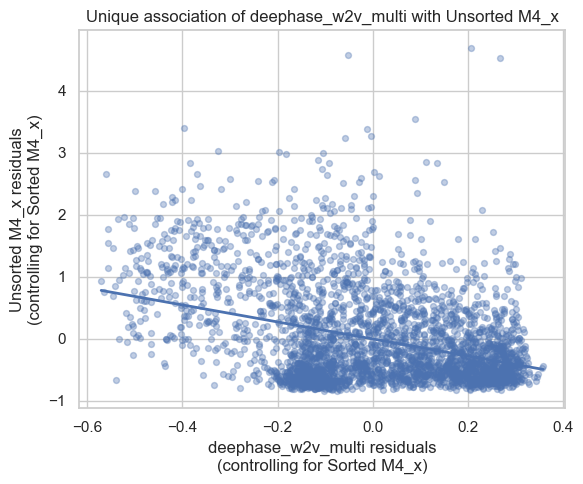

In [63]:
# Unsorted M4_x ~ Sorted M4_x + deephase_w2v_multi
# Ask directly how much deephase_w2v_multi adds beyond Sorted M4_x alone.

simple_df = final_df[["Unsorted M4_x", "Sorted M4_x", "deephase_w2v_multi"]].copy()
simple_df["Unsorted M4_x"] = pd.to_numeric(simple_df["Unsorted M4_x"], errors="coerce")
simple_df["Sorted M4_x"] = pd.to_numeric(simple_df["Sorted M4_x"], errors="coerce")
simple_df["deephase_w2v_multi"] = pd.to_numeric(simple_df["deephase_w2v_multi"], errors="coerce")
simple_df = simple_df.dropna().reset_index(drop=True)

simple_base_model = fit_ols(simple_df, ["Sorted M4_x"], "Unsorted M4_x")
simple_full_model = fit_ols(simple_df, ["Sorted M4_x", "deephase_w2v_multi"], "Unsorted M4_x")

simple_delta_r2 = simple_full_model["r_squared"] - simple_base_model["r_squared"]

unsorted_resid_simple = residualize(simple_df, "Unsorted M4_x", ["Sorted M4_x"])
deephase_resid_simple = residualize(simple_df, "deephase_w2v_multi", ["Sorted M4_x"])
simple_partial_r, simple_partial_p = pearsonr(deephase_resid_simple, unsorted_resid_simple)

print("=== Data used ===")
print(f"Rows used: {len(simple_df)}")
print()
print("=== Reduced model ===")
print("Unsorted M4_x ~ Sorted M4_x")
print(f"R^2 = {simple_base_model['r_squared']:.4f}")
print()
print("=== Full model ===")
print("Unsorted M4_x ~ Sorted M4_x + deephase_w2v_multi")
print(f"R^2 = {simple_full_model['r_squared']:.4f}")
for var, coef, se, t_stat, p_val in zip(
    simple_full_model["variables"],
    simple_full_model["coefficients"],
    simple_full_model["std_error"],
    simple_full_model["t_stats"],
    simple_full_model["p_values"],
):
    print(f"{var:20s} coef={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")
print()
print("=== Extra variance explained by deephase_w2v_multi ===")
print(f"Delta R^2 = {simple_delta_r2:.4f} ({simple_delta_r2 * 100:.2f}% additional variance explained)")
print(f"Partial Pearson r = {simple_partial_r:.4f}, p = {simple_partial_p:.2e}")

plt.figure(figsize=(6, 5))
plt.scatter(deephase_resid_simple, unsorted_resid_simple, alpha=0.35, s=18)
z = np.polyfit(deephase_resid_simple, unsorted_resid_simple, 1)
p_line = np.poly1d(z)
x_line = np.linspace(deephase_resid_simple.min(), deephase_resid_simple.max(), 200)
plt.plot(x_line, p_line(x_line), linewidth=2)
plt.xlabel("deephase_w2v_multi residuals\n(controlling for Sorted M4_x)")
plt.ylabel("Unsorted M4_x residuals\n(controlling for Sorted M4_x)")
plt.title("Unique association of deephase_w2v_multi with Unsorted M4_x")
plt.tight_layout()
plt.show()


=== Pairwise Pearson correlations ===
protein_length       vs deephase_w2v_multi   r = 0.4409, p = 2.08e-152
protein_length       vs Unsorted M4_x        r = -0.6804, p = 0.00e+00
deephase_w2v_multi   vs Unsorted M4_x        r = -0.3646, p = 3.03e-101

=== Model comparison: who absorbs whose signal? ===
Unsorted M4_x ~ protein_length                     R^2 = 0.4629
Unsorted M4_x ~ protein_length + deephase_w2v_multi R^2 = 0.4681
Extra R^2 from deephase after length = 0.0052

Unsorted M4_x ~ deephase_w2v_multi                  R^2 = 0.1330
Unsorted M4_x ~ deephase_w2v_multi + protein_length R^2 = 0.4681
Extra R^2 from length after deephase = 0.3352

=== Residual association after removing protein_length ===
Partial Pearson r = -0.0982, p = 2.55e-08


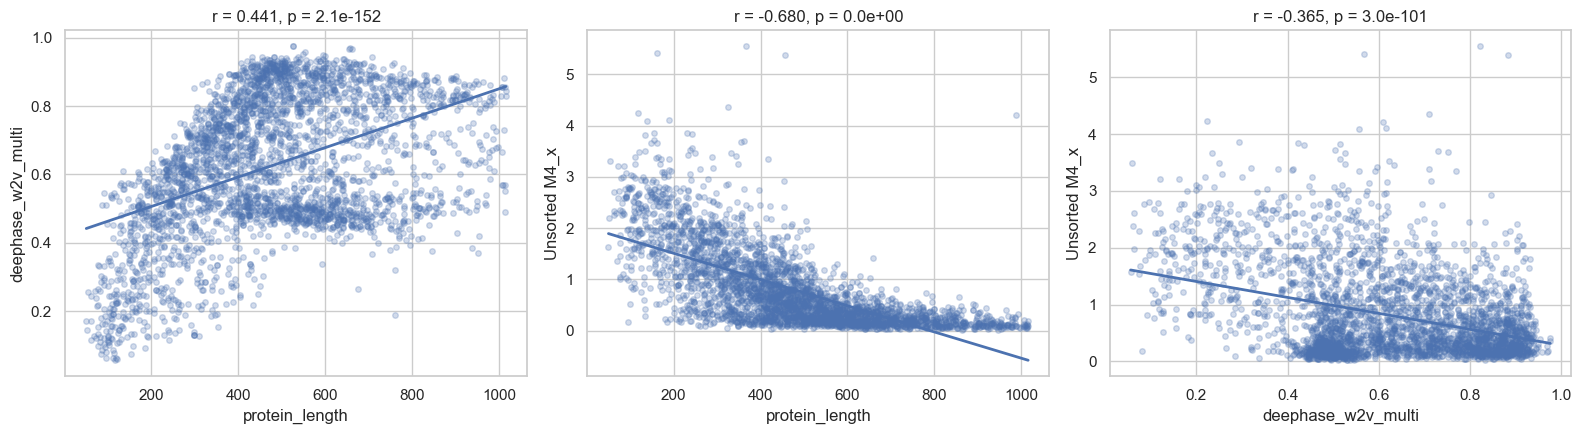

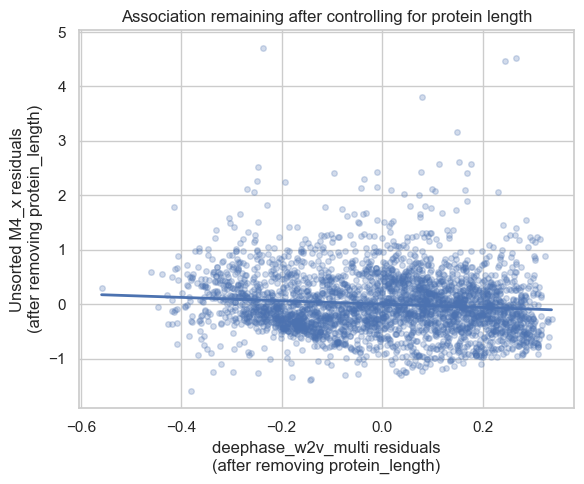

In [64]:
# Explore whether protein_length captures the same major axis as deephase_w2v_multi.

length_df = analysis_df[["Unsorted M4_x", "deephase_w2v_multi", "protein_length"]].dropna().copy()

pairs = [
    ("protein_length", "deephase_w2v_multi"),
    ("protein_length", "Unsorted M4_x"),
    ("deephase_w2v_multi", "Unsorted M4_x"),
]

print("=== Pairwise Pearson correlations ===")
for x_col, y_col in pairs:
    r_val, p_val = pearsonr(length_df[x_col], length_df[y_col])
    print(f"{x_col:20s} vs {y_col:20s} r = {r_val:.4f}, p = {p_val:.2e}")

length_only_model = fit_ols(length_df, ["protein_length"], "Unsorted M4_x")
length_plus_deephase_model = fit_ols(length_df, ["protein_length", "deephase_w2v_multi"], "Unsorted M4_x")
deephase_only_model = fit_ols(length_df, ["deephase_w2v_multi"], "Unsorted M4_x")
deephase_plus_length_model = fit_ols(length_df, ["deephase_w2v_multi", "protein_length"], "Unsorted M4_x")

print()
print("=== Model comparison: who absorbs whose signal? ===")
print(f"Unsorted M4_x ~ protein_length                     R^2 = {length_only_model['r_squared']:.4f}")
print(f"Unsorted M4_x ~ protein_length + deephase_w2v_multi R^2 = {length_plus_deephase_model['r_squared']:.4f}")
print(f"Extra R^2 from deephase after length = {length_plus_deephase_model['r_squared'] - length_only_model['r_squared']:.4f}")
print()
print(f"Unsorted M4_x ~ deephase_w2v_multi                  R^2 = {deephase_only_model['r_squared']:.4f}")
print(f"Unsorted M4_x ~ deephase_w2v_multi + protein_length R^2 = {deephase_plus_length_model['r_squared']:.4f}")
print(f"Extra R^2 from length after deephase = {deephase_plus_length_model['r_squared'] - deephase_only_model['r_squared']:.4f}")

deephase_resid_after_length = residualize(length_df, "deephase_w2v_multi", ["protein_length"])
unsorted_resid_after_length = residualize(length_df, "Unsorted M4_x", ["protein_length"])
r_after_length, p_after_length = pearsonr(deephase_resid_after_length, unsorted_resid_after_length)

print()
print("=== Residual association after removing protein_length ===")
print(f"Partial Pearson r = {r_after_length:.4f}, p = {p_after_length:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (x_col, y_col) in zip(axes, pairs):
    x = length_df[x_col].to_numpy(dtype=float)
    y = length_df[y_col].to_numpy(dtype=float)
    ax.scatter(x, y, alpha=0.25, s=16)
    z = np.polyfit(x, y, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, p_line(x_line), linewidth=2)
    r_val, p_val = pearsonr(x, y)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"r = {r_val:.3f}, p = {p_val:.1e}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(deephase_resid_after_length, unsorted_resid_after_length, alpha=0.25, s=16)
z = np.polyfit(deephase_resid_after_length, unsorted_resid_after_length, 1)
p_line = np.poly1d(z)
x_line = np.linspace(deephase_resid_after_length.min(), deephase_resid_after_length.max(), 200)
plt.plot(x_line, p_line(x_line), linewidth=2)
plt.xlabel("deephase_w2v_multi residuals\n(after removing protein_length)")
plt.ylabel("Unsorted M4_x residuals\n(after removing protein_length)")
plt.title("Association remaining after controlling for protein length")
plt.tight_layout()
plt.show()


=== Interaction model ===
Unsorted M4_x ~ protein_length + deephase_w2v_multi + protein_length:deephase_w2v_multi
Rows used: 3201

Main-effects-only model:
R^2 = 0.4681

Interaction model:
R^2 = 0.4977
intercept            coef= 0.752744, SE=0.010574, t=71.187, p=0.00e+00
length_centered      coef=-0.002305, SE=0.000053, t=-43.329, p=0.00e+00
deephase_centered    coef=-0.142764, SE=0.055091, t=-2.591, p=9.60e-03
length_x_deephase    coef= 0.003201, SE=0.000233, t=13.724, p=0.00e+00

Extra variance explained by the interaction:
Delta R^2 = 0.0296 (2.96% additional variance explained)

Interpretation note:
If length_x_deephase is significant, the association between condensation and Unsorted M4_x depends on protein length.
A negative interaction coefficient means the condensation-associated drop in Unsorted M4_x becomes stronger as proteins get longer.
A positive interaction coefficient means the condensation effect becomes weaker as proteins get longer.


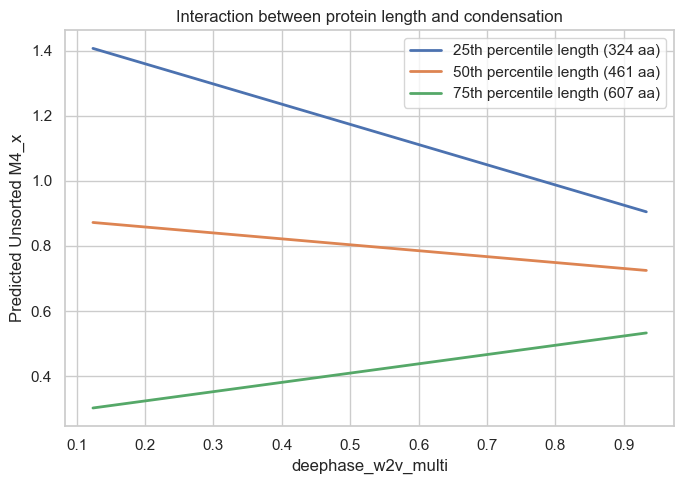

In [65]:
# Interaction model: does condensation matter more in longer proteins?

interaction_df = analysis_df[["Unsorted M4_x", "protein_length", "deephase_w2v_multi"]].dropna().copy()
interaction_df["length_centered"] = interaction_df["protein_length"] - interaction_df["protein_length"].mean()
interaction_df["deephase_centered"] = interaction_df["deephase_w2v_multi"] - interaction_df["deephase_w2v_multi"].mean()
interaction_df["length_x_deephase"] = (
    interaction_df["length_centered"] * interaction_df["deephase_centered"]
)

main_effect_model = fit_ols(
    interaction_df,
    ["length_centered", "deephase_centered"],
    "Unsorted M4_x"
)

interaction_model = fit_ols(
    interaction_df,
    ["length_centered", "deephase_centered", "length_x_deephase"],
    "Unsorted M4_x"
)

interaction_delta_r2 = interaction_model["r_squared"] - main_effect_model["r_squared"]

print("=== Interaction model ===")
print("Unsorted M4_x ~ protein_length + deephase_w2v_multi + protein_length:deephase_w2v_multi")
print(f"Rows used: {len(interaction_df)}")
print()
print("Main-effects-only model:")
print(f"R^2 = {main_effect_model['r_squared']:.4f}")
print()
print("Interaction model:")
print(f"R^2 = {interaction_model['r_squared']:.4f}")
for var, coef, se, t_stat, p_val in zip(
    interaction_model["variables"],
    interaction_model["coefficients"],
    interaction_model["std_error"],
    interaction_model["t_stats"],
    interaction_model["p_values"],
):
    print(f"{var:20s} coef={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")
print()
print("Extra variance explained by the interaction:")
print(f"Delta R^2 = {interaction_delta_r2:.4f} ({interaction_delta_r2 * 100:.2f}% additional variance explained)")
print()
print("Interpretation note:")
print("If length_x_deephase is significant, the association between condensation and Unsorted M4_x depends on protein length.")
print("A negative interaction coefficient means the condensation-associated drop in Unsorted M4_x becomes stronger as proteins get longer.")
print("A positive interaction coefficient means the condensation effect becomes weaker as proteins get longer.")

length_low = interaction_df["protein_length"].quantile(0.25)
length_mid = interaction_df["protein_length"].quantile(0.50)
length_high = interaction_df["protein_length"].quantile(0.75)

coef_map = dict(zip(interaction_model["variables"], interaction_model["coefficients"]))
intercept = coef_map["intercept"]
b_len = coef_map["length_centered"]
b_deephase = coef_map["deephase_centered"]
b_int = coef_map["length_x_deephase"]

deephase_grid = np.linspace(
    interaction_df["deephase_w2v_multi"].quantile(0.01),
    interaction_df["deephase_w2v_multi"].quantile(0.99),
    200,
)

plt.figure(figsize=(7, 5))
for length_value, label in [
    (length_low, "25th percentile length"),
    (length_mid, "50th percentile length"),
    (length_high, "75th percentile length"),
]:
    lc = length_value - interaction_df["protein_length"].mean()
    dc = deephase_grid - interaction_df["deephase_w2v_multi"].mean()
    y_hat = intercept + b_len * lc + b_deephase * dc + b_int * (lc * dc)
    plt.plot(deephase_grid, y_hat, linewidth=2, label=f"{label} ({length_value:.0f} aa)")

plt.xlabel("deephase_w2v_multi")
plt.ylabel("Predicted Unsorted M4_x")
plt.title("Interaction between protein length and condensation")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Length-stratified analysis: test whether the deephase effect changes across protein-length quartiles.

if "analysis_df" not in globals():
    analysis_df = prepare_unsorted_m4_multivar_data(final_df)

strat_df = analysis_df[["Unsorted M4_x", "deephase_w2v_multi", "Sorted M4_x", "protein_length"]].dropna().copy()
strat_df["length_quartile"] = pd.qcut(
    strat_df["protein_length"],
    q=4,
    labels=["Q1 shortest", "Q2", "Q3", "Q4 longest"],
)

strat_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for ax, quartile in zip(axes.flat, ["Q1 shortest", "Q2", "Q3", "Q4 longest"]):
    sub = strat_df[strat_df["length_quartile"] == quartile].copy()

    model_deephase = fit_ols(sub, ["deephase_w2v_multi"], "Unsorted M4_x")
    model_with_cov = fit_ols(sub, ["deephase_w2v_multi", "Sorted M4_x"], "Unsorted M4_x")
    delta_r2 = model_with_cov["r_squared"] - fit_ols(sub, ["Sorted M4_x"], "Unsorted M4_x")["r_squared"]
    r_raw, p_raw = pearsonr(sub["deephase_w2v_multi"], sub["Unsorted M4_x"])

    coef_map = dict(zip(model_with_cov["variables"], model_with_cov["coefficients"]))
    p_map = dict(zip(model_with_cov["variables"], model_with_cov["p_values"]))
    strat_rows.append({
        "quartile": quartile,
        "n": len(sub),
        "length_min": sub["protein_length"].min(),
        "length_max": sub["protein_length"].max(),
        "raw_r_deephase_vs_m4": r_raw,
        "raw_p_deephase_vs_m4": p_raw,
        "r2_deephase_only": model_deephase["r_squared"],
        "r2_deephase_plus_sorted": model_with_cov["r_squared"],
        "delta_r2_deephase_given_sorted": delta_r2,
        "deephase_coef_given_sorted": coef_map["deephase_w2v_multi"],
        "deephase_p_given_sorted": p_map["deephase_w2v_multi"],
    })

    x = sub["deephase_w2v_multi"].to_numpy(dtype=float)
    y = sub["Unsorted M4_x"].to_numpy(dtype=float)
    ax.scatter(x, y, alpha=0.25, s=16)
    z = np.polyfit(x, y, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, p_line(x_line), linewidth=2)
    ax.set_title(quartile)
    ax.set_xlabel("deephase_w2v_multi")
    ax.set_ylabel("Unsorted M4_x")
    ax.text(
        0.03,
        0.97,
        f"n = {len(sub)}\nr = {r_raw:.3f}\nDelta R^2 = {delta_r2:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.show()

strat_results_df = pd.DataFrame(strat_rows)
print("=== Length-stratified analysis ===")
print(strat_results_df.to_string(index=False))


In [ ]:
# Gene-level interaction: does the length-by-condensation pattern remain after collapsing isoforms?

gene_interaction_df = prepare_gene_level_data(
    final_df,
    gene_col="RefSeq Gene Name_x",
    isoform_col="Isoform ID_x",
    score_col="deephase_w2v_multi",
    m4_col="Unsorted M4_x",
    seq_col="protein_seq_x",
).copy()

gene_interaction_df["deephase_w2v_multi"] = pd.to_numeric(gene_interaction_df["deephase_w2v_multi"], errors="coerce")
gene_interaction_df = gene_interaction_df.dropna(subset=["deephase_w2v_multi", "Unsorted M4_x", "protein_length"]).copy()
gene_interaction_df["length_centered"] = gene_interaction_df["protein_length"] - gene_interaction_df["protein_length"].mean()
gene_interaction_df["deephase_centered"] = gene_interaction_df["deephase_w2v_multi"] - gene_interaction_df["deephase_w2v_multi"].mean()
gene_interaction_df["length_x_deephase"] = (
    gene_interaction_df["length_centered"] * gene_interaction_df["deephase_centered"]
)

gene_main_model = fit_ols(
    gene_interaction_df,
    ["length_centered", "deephase_centered"],
    "Unsorted M4_x",
)
gene_full_model = fit_ols(
    gene_interaction_df,
    ["length_centered", "deephase_centered", "length_x_deephase"],
    "Unsorted M4_x",
)

print("=== Gene-level interaction model ===")
print("Unsorted M4_x ~ protein_length + deephase_w2v_multi + protein_length:deephase_w2v_multi")
print(f"Rows used: {len(gene_interaction_df)}")
print(f"Main-effects R^2 = {gene_main_model['r_squared']:.4f}")
print(f"Interaction-model R^2 = {gene_full_model['r_squared']:.4f}")
print(f"Delta R^2 = {gene_full_model['r_squared'] - gene_main_model['r_squared']:.4f}")
print()
for var, coef, se, t_stat, p_val in zip(
    gene_full_model["variables"],
    gene_full_model["coefficients"],
    gene_full_model["std_error"],
    gene_full_model["t_stats"],
    gene_full_model["p_values"],
):
    print(f"{var:20s} coef={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")


In [ ]:
# Check whether a nonlinear length term explains the apparent interaction.

nonlinear_df = analysis_df[["Unsorted M4_x", "protein_length", "deephase_w2v_multi"]].dropna().copy()
nonlinear_df["length_centered"] = nonlinear_df["protein_length"] - nonlinear_df["protein_length"].mean()
nonlinear_df["deephase_centered"] = nonlinear_df["deephase_w2v_multi"] - nonlinear_df["deephase_w2v_multi"].mean()
nonlinear_df["length_sq"] = nonlinear_df["length_centered"] ** 2
nonlinear_df["length_x_deephase"] = nonlinear_df["length_centered"] * nonlinear_df["deephase_centered"]

linear_model = fit_ols(
    nonlinear_df,
    ["length_centered", "deephase_centered"],
    "Unsorted M4_x",
)
quadratic_model = fit_ols(
    nonlinear_df,
    ["length_centered", "length_sq", "deephase_centered"],
    "Unsorted M4_x",
)
quadratic_interaction_model = fit_ols(
    nonlinear_df,
    ["length_centered", "length_sq", "deephase_centered", "length_x_deephase"],
    "Unsorted M4_x",
)

print("=== Length nonlinearity check ===")
print(f"Linear main-effects model R^2 = {linear_model['r_squared']:.4f}")
print(f"Add length^2 R^2 = {quadratic_model['r_squared']:.4f}")
print(f"Delta R^2 from length^2 = {quadratic_model['r_squared'] - linear_model['r_squared']:.4f}")
print()
print(f"Add length^2 + interaction R^2 = {quadratic_interaction_model['r_squared']:.4f}")
print(f"Delta R^2 from interaction after length^2 = {quadratic_interaction_model['r_squared'] - quadratic_model['r_squared']:.4f}")
print()
for var, coef, se, t_stat, p_val in zip(
    quadratic_interaction_model["variables"],
    quadratic_interaction_model["coefficients"],
    quadratic_interaction_model["std_error"],
    quadratic_interaction_model["t_stats"],
    quadratic_interaction_model["p_values"],
):
    print(f"{var:20s} coef={coef: .6f}, SE={se:.6f}, t={t_stat:.3f}, p={p_val:.2e}")

length_grid = np.linspace(
    nonlinear_df["protein_length"].quantile(0.01),
    nonlinear_df["protein_length"].quantile(0.99),
    200,
)
lc_grid = length_grid - nonlinear_df["protein_length"].mean()
coef_map = dict(zip(quadratic_model["variables"], quadratic_model["coefficients"]))
y_curve = (
    coef_map["intercept"]
    + coef_map["length_centered"] * lc_grid
    + coef_map["length_sq"] * (lc_grid ** 2)
)

plt.figure(figsize=(6, 5))
plt.scatter(nonlinear_df["protein_length"], nonlinear_df["Unsorted M4_x"], alpha=0.15, s=12)
plt.plot(length_grid, y_curve, linewidth=2)
plt.xlabel("protein_length")
plt.ylabel("Predicted Unsorted M4_x")
plt.title("Quadratic length trend for Unsorted M4_x")
plt.tight_layout()
plt.show()
